In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("特征矩阵 X 的形状：", X.shape)
print("标签 y 的形状：", y.shape)
print("类别名称：", data.target_names)
print("特征名称数量：", len(data.feature_names))

特征矩阵 X 的形状： (569, 30)
标签 y 的形状： (569,)
类别名称： ['malignant' 'benign']
特征名称数量： 30


In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("测试集准确率：", acc)

测试集准确率： 0.956140350877193


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("每一折的准确率：", scores)
print("平均准确率：", scores.mean())
print("准确率标准差：", scores.std())

每一折的准确率： [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
平均准确率： 0.9560937742586555
准确率标准差： 0.02283883380490945


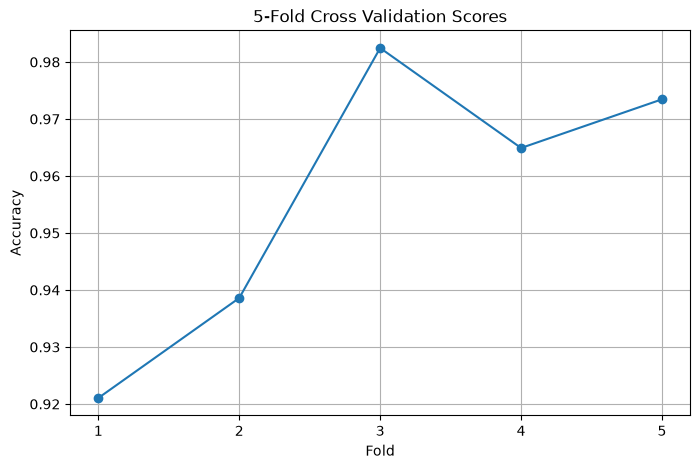

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), scores, marker="o")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Scores")
plt.xticks(range(1, 6))
plt.grid(True)
plt.show()

In [8]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [9]:
base_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

In [10]:
print("最优参数：")
print(grid_search.best_params_)

print("交叉验证最佳得分：")
print(grid_search.best_score_)

最优参数：
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
交叉验证最佳得分：
0.9604395604395606


In [11]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

best_acc = accuracy_score(y_test, y_pred_best)

print("调参后测试集准确率：", best_acc)

调参后测试集准确率： 0.956140350877193


In [12]:
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [13]:
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)

print("默认模型准确率：", baseline_acc)
print("网格搜索后准确率：", best_acc)

默认模型准确率： 0.956140350877193
网格搜索后准确率： 0.956140350877193


In [14]:
results = pd.DataFrame(grid_search.cv_results_)

results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.153661,0.018094,0.011569,0.002370,None,1,2,50,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.967033,0.989011,0.923077,0.923077,0.956044,0.951648,0.025631,63
1,0.350353,0.032503,0.021600,0.004539,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.967033,0.989011,0.923077,0.934066,0.956044,0.953846,0.023466,30
2,0.669019,0.074261,0.037210,0.006518,None,1,2,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.967033,0.989011,0.934066,0.945055,0.967033,0.960440,0.019160,1
3,0.173538,0.013437,0.009466,0.001322,None,1,5,50,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.978022,0.989011,0.923077,0.945055,0.956044,0.958242,0.023466,7
4,0.367012,0.054876,0.019373,0.001421,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.978022,0.989011,0.934066,0.923077,0.945055,0.953846,0.025441,30


In [15]:
results_simple = results[
    [
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf"
    ]
]

results_simple = results_simple.sort_values(
    by="mean_test_score",
    ascending=False
)

results_simple.head(10)

,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf
2,0.960440,0.019160,200,None,2,1
12,0.960440,0.025631,50,None,5,2
25,0.960440,0.022628,100,None,10,4
93,0.960440,0.025631,50,10,5,2
106,0.960440,0.022628,100,10,10,4
83,0.960440,0.019160,200,10,2,1
19,0.958242,0.025441,100,None,2,4
84,0.958242,0.023466,50,10,5,1
65,0.958242,0.022413,200,5,2,2
22,0.958242,0.025441,100,None,5,4


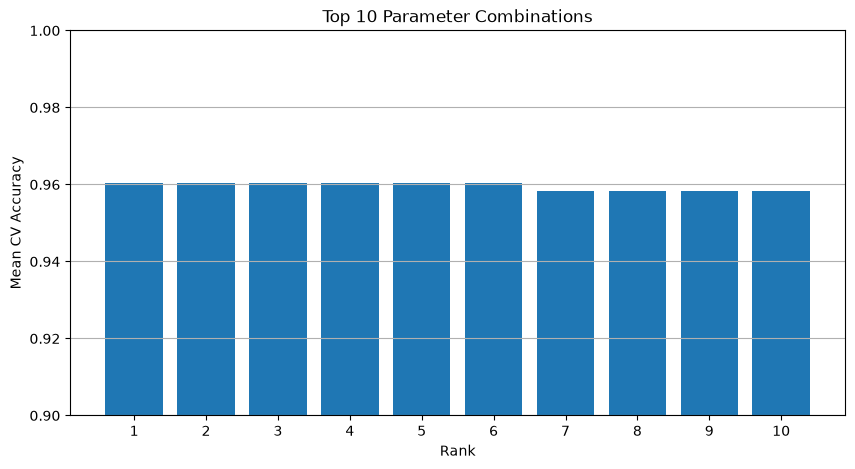

In [16]:
top10 = results_simple.head(10).copy()
top10["rank"] = range(1, 11)

plt.figure(figsize=(10, 5))
plt.bar(top10["rank"], top10["mean_test_score"])
plt.xlabel("Rank")
plt.ylabel("Mean CV Accuracy")
plt.title("Top 10 Parameter Combinations")
plt.xticks(top10["rank"])
plt.ylim(0.9, 1.0)
plt.grid(axis="y")
plt.show()

In [17]:
param_dist = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"]
}

In [18]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Al

In [19]:
print("随机搜索最优参数：")
print(random_search.best_params_)

print("随机搜索交叉验证最佳得分：")
print(random_search.best_score_)

随机搜索最优参数：
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
随机搜索交叉验证最佳得分：
0.9582417582417584


In [20]:
random_best_model = random_search.best_estimator_

random_pred = random_best_model.predict(X_test)

random_acc = accuracy_score(y_test, random_pred)

print("随机搜索后测试集准确率：", random_acc)

随机搜索后测试集准确率： 0.956140350877193


In [21]:
comparison = pd.DataFrame({
    "方法": ["默认随机森林", "GridSearchCV", "RandomizedSearchCV"],
    "测试集准确率": [baseline_acc, best_acc, random_acc]
})

comparison

,方法,测试集准确率
0,默认随机森林,0.95614
1,GridSearchCV,0.95614
2,RandomizedSearchCV,0.95614


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40664 (\N{CJK UNIFIED IDEOGRAPH-9ED8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35748 (\N{CJK UNIFIED IDEOGRAPH-8BA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/penglei/projects/ml-learning/.venv/lib/python3.12/

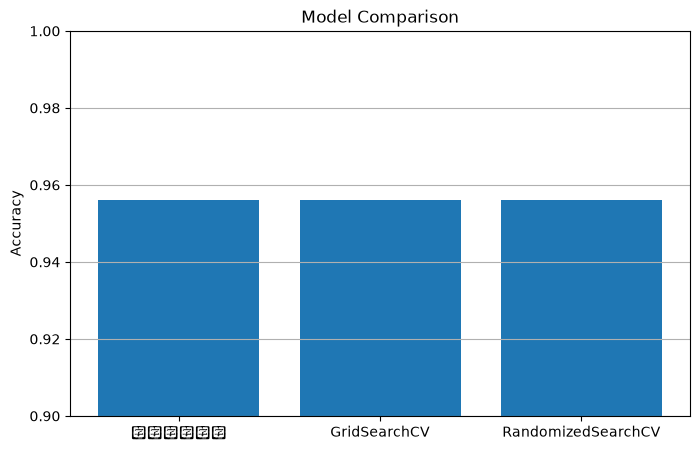

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["方法"], comparison["测试集准确率"])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.9, 1.0)
plt.grid(axis="y")
plt.show()